In [45]:
%matplotlib inline

In [46]:
import xtrack as xt
import xpart as xp
import matplotlib.pyplot as plt

import numpy as np

In [47]:
p0_carbon = xt.Particles('Carbon-12', q0=6)
p0_helium = xt.Particles('Helium-4', q0=2)

In [48]:
p0_carbon.pdg_id, p0_helium.pdg_id

(array([1000060120]), array([1000020040]))

In [49]:
mass_ratio_he_ca = p0_helium.mass0 / p0_carbon.mass0
charge_ratio_he_ca = p0_helium.q0 / p0_carbon.q0

In [50]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')

line = env.ring
line.configure_bend_model(core='bend-kick-bend')#num_multipole_kicks=5)
line.set_particle_ref('Carbon-12', q0=6, kinetic_energy0=200e6 * 12)

tw4d = line.twiss4d()
eta = tw4d.slip_factor
line_length = tw4d.line_length

line['vrf'] = 0 # Debunched beam
line['frf'] = 1 / tw4d.t_rev0 # h=1

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

In [51]:
opt = line.match(
    solve=False, # <- prepare the match without running it
    chrom=False,
    method='4d',
    vary=[
        xt.Vary('kqfa', limits=(0, 10),  step=1e-3),
        xt.Vary('kqfb', limits=(0, 10),  step=1e-3),
        xt.Vary('kqd', limits=(-10, 0), step=1e-3),
    ],
    targets=[
        xt.TargetSet(qx=1.665, qy=1.72, tol=1e-4),
        xt.TargetSet(dx=0, at='mid.lss.0', tol=2e-3),
        xt.TargetSet(dx=0, at='mid.lss.1', tol=2e-3),
    ]
)
opt.step(20)
opt.target_status()

                                             
Optimize - start penalty: 0.2499                            
Matching: model call n. 13 penalty = 1.5294e-05              
Optimize - end penalty:  1.52945e-05                            
Target status:               nalty = 1.5294e-05              
id state tag          tol_met       residue   current_val    target_val description                                 
0  ON    qx              True   3.39148e-07         1.665         1.665 'qx', val=1.665, tol=0.0001, weight=10      
1  ON    qy              True   2.54395e-08          1.72          1.72 'qy', val=1.72, tol=0.0001, weight=10       
2  ON    mid.lss.0_dx    True  -1.05248e-06  -1.05248e-06             0 ('dx', 'mid.lss.0'), val=0, tol=0.002, w ...
3  ON    mid.lss.1_dx    True  -1.05633e-06  -1.05633e-06             0 ('dx', 'mid.lss.1'), val=0, tol=0.002, w ...


In [52]:
env.new('extr_septum', xt.Marker)
env.new('septum_aperture', xt.LimitRect, min_x=-0.1, max_x=0.1, min_y=-0.1, max_y=0.1),

line.insert(['extr_septum', 'septum_aperture'], at=0)



Slicing line:   0%|          | 0/109 [00:00<?, ?it/s]

In [77]:
env['kse'] = 3.

In [78]:
x_gen = np.linspace(0, 1e-2, 20)
p = line.build_particles(x=x_gen, px=0, y=0, py=0, zeta=0, delta=0)

In [79]:
line.track(p, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

In [80]:
rec = line.record_last_track

In [83]:
x_septum = 3.5e-2

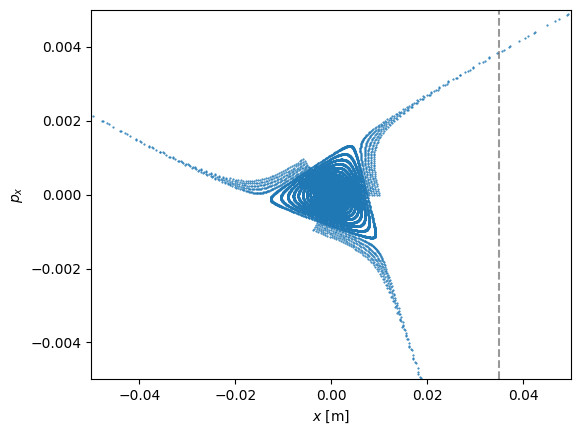

In [84]:
# Plot turn-by-turn data
plt.figure()
plt.plot(rec.x.T, rec.px.T, '.', markersize=1, color='C0')
plt.xlabel(r'$x$ [m]'); plt.ylabel(r'$p_x$'), plt.xlim(-5e-2, 5e-2); plt.ylim(-5e-3, 5e-3)
plt.axvline(x=x_septum, color='k', alpha=0.4, linestyle='--')
plt.subplots_adjust(left=.15)